Importar librerias

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [28]:
# Cargar el archivo CSV
df = pd.read_csv('datos_filtrados.csv', encoding='ISO-8859-1', on_bad_lines='skip', delimiter=',')

# Ver las primeras filas del DataFrame
df.head()

,Unnamed: 0,bathrooms,bedrooms,has_photo,price,square_feet,address,cityname,state,latitude,...,TV,Tennis,View,Washer Dryer,Wood Floors,noamenities,Cats,"Cats,Dogs",Dogs,petsunknown
0,2,1.0,0.0,1,1390,107,addressunknown,Arlington,VA,38.8910,...,0,0,0,0,0,1,0,0,0,1
1,3,1.0,0.0,1,925,116,1717 12th Avenue,Seattle,WA,47.6160,...,0,0,0,0,0,1,0,0,0,1
2,5,1.0,0.0,1,2475,130,350 West 50th St,Manhattan,NY,40.7629,...,0,0,0,0,0,0,0,0,0,1
3,8,1.0,0.0,1,1495,138,333 Hyde St,San Francisco,CA,37.7599,...,0,0,0,0,0,0,0,0,0,1
4,14,1.0,0.0,1,1695,190,57 Taylor St,San Francisco,CA,37.7599,...,0,0,0,0,0,0,0,0,0,1


In [29]:
Variable_interes=["price"]

y=df[Variable_interes]

Variables_influyentes = df.columns.tolist()
Variables_influyentes.remove("price")
Variables_influyentes.remove("Unnamed: 0")
Variables_influyentes.remove("address")
Variables_influyentes.remove("cityname")
Variables_influyentes.remove("latitude")
Variables_influyentes.remove("longitude")
Variables_influyentes.remove("source")
Variables_influyentes.remove("time")


x=df[Variables_influyentes]

#Generar dummies
x = pd.get_dummies(x, drop_first=True).astype(float)

x.head()


,bathrooms,bedrooms,has_photo,square_feet,AC,Alarm,Basketball,Cable or Satellite,Clubhouse,Dishwasher,...,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY
0,1.0,0.0,1.0,107.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,1.0,116.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,1.0,130.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,138.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,1.0,190.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Análisis Estadístico

In [30]:
x = sm.add_constant(x)
x

,bathrooms,bedrooms,has_photo,square_feet,AC,Alarm,Basketball,Cable or Satellite,Clubhouse,Dishwasher,...,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY
0,1.0,0.0,1.0,107.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,1.0,116.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,1.0,130.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,138.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,1.0,190.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9269,4.0,5.0,1.0,3966.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9270,3.5,5.0,1.0,4000.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9271,4.5,4.0,1.0,4500.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9272,3.5,5.0,1.0,4614.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
An = sm.OLS(y, x)  # Crea el modelo
results = An.fit()

In [32]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     157.7
Date:                Mon, 24 Feb 2025   Prob (F-statistic):               0.00
Time:                        15:29:32   Log-Likelihood:                -66643.
No. Observations:                9274   AIC:                         1.335e+05
Df Residuals:                    9189   BIC:                         1.341e+05
Df Model:                          84                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
bathrooms            119.0449     10

In [33]:
# Get p-values from the results
p_values = results.pvalues

# Filter variables with p-value greater than 0.07
non_significant_vars = p_values[p_values > 0.07].index.tolist()

print("Variables no significativas:", non_significant_vars)

Variables no significativas: ['Alarm', 'Clubhouse', 'Doorman', 'Gated', 'Golf', 'Hot Tub', 'Luxury', 'Patio/Deck', 'Storage', 'Washer Dryer', 'state_AL', 'state_AZ', 'state_DE', 'state_GA', 'state_ID', 'state_IN', 'state_MI', 'state_MT', 'state_NC', 'state_NM', 'state_NV', 'state_OH', 'state_TX', 'state_UT']


In [34]:
for i in non_significant_vars[:10]:
    Variables_influyentes.remove(i)

In [35]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Supongamos que tienes un DataFrame con columnas 'feature1' y 'feature2'
df['baños*area'] = df['bathrooms'] * df['square_feet']
df['cuartos*area'] = df['bedrooms'] * df['square_feet']
df['cuartos*baños'] = df['bedrooms'] * df['bathrooms']


In [36]:
Variables_influyentes.append('baños*area')
Variables_influyentes.append('cuartos*area')
Variables_influyentes.append('cuartos*baños')

x=df[Variables_influyentes]

#Generar dummies
x = pd.get_dummies(x, drop_first=True).astype(float)

x = sm.add_constant(x)

An = sm.OLS(y, x)  # Crea el modelo
results = An.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     175.8
Date:                Mon, 24 Feb 2025   Prob (F-statistic):               0.00
Time:                        15:29:33   Log-Likelihood:                -66586.
No. Observations:                9274   AIC:                         1.333e+05
Df Residuals:                    9196   BIC:                         1.339e+05
Df Model:                          77                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
bathrooms             47.0655     27

In [37]:
results.params.tolist()

[47.065483111379415,
 15.255505732955063,
 321.1980943749032,
 0.7553312905010516,
 -86.76930908160733,
 -72.99038857309955,
 -49.298864305965495,
 28.57116132392455,
 193.60692976413162,
 -25.836929633416155,
 -60.48464967397635,
 77.39730765982368,
 63.961271453708896,
 59.728402301434336,
 -145.9820713732418,
 32.280659080576584,
 -32.16393941362982,
 64.10687807821503,
 -55.48900242853851,
 84.43981099824354,
 108.4782827233472,
 80.04455841516365,
 47.059657005100576,
 86.51819031061146,
 138.574363101508,
 49.045883945585445,
 -0.05729680603856764,
 -0.08177358462443542,
 56.610855352203366,
 -138.05095540965974,
 -325.7656960566782,
 -10.605399752679116,
 918.3885453989623,
 232.19741697441367,
 190.60155325079975,
 964.9206067969018,
 39.41536596161251,
 174.44946021839667,
 11.655485162012948,
 971.8145254768853,
 -195.97446806921593,
 123.85187134260616,
 236.67485520590594,
 -95.29664773893478,
 -196.70720898114953,
 -189.22662769180315,
 -180.01779497254523,
 884.1552674284

In [38]:
# disntacia de Cook
resultados_cooksd = results.get_influence().cooks_distance[0]

# get length of df to obtain n
n = x.shape[0]

# umbral
critical_d = 4/n
print('Umbral con distancia de Cook:', critical_d)

# puntos que podrían ser ourliers con alta influencia
out_d = resultados_cooksd > critical_d

print(x.index[out_d], "\n", resultados_cooksd[out_d])

Umbral con distancia de Cook: 0.00043131334914815614
Index([   2,    5,    6,   14,  188,  190,  193,  210,  227,  238,
       ...
       9257, 9258, 9259, 9260, 9263, 9264, 9266, 9268, 9269, 9271],
      dtype='int64', length=452) 
 [5.43536749e-03 1.64355580e-03 1.64355580e-03 5.29555396e-03
 5.78258756e-04 1.31982728e-03 6.82994158e-04 1.74612305e-03
 6.27180058e-04 1.45543504e-03 4.86493683e-04 6.01427920e-04
 6.49043748e-04 5.32464246e-04 7.83707990e-03 5.16757705e-04
 5.44549312e-04 1.39806069e-03 4.54698736e-04 5.46097236e-03
 1.03624747e-03 5.26434844e-04 4.61230221e-04 5.91570972e-04
 6.75665400e-04 5.48137482e-03 1.03204391e-03 4.84909242e-04
 5.21223897e-04 1.61582760e-03 8.16078798e-04 1.14979220e-03
 4.36339211e-04 6.74227315e-04 7.12913380e-04 1.33006280e-03
 1.04903034e-03 6.64231102e-04 1.65644823e-03 7.85084539e-04
 4.61986393e-04 4.91560454e-04 1.38717826e-03 4.47465714e-04
 6.61469534e-04 4.42468248e-04 6.49935344e-04 1.02787735e-03
 4.80512374e-04 8.85920063e-04 4.8

In [39]:
import pandas as pd

#Remover los outliers influyentes

indices_a_remover = x.index[out_d].tolist()  

df = df.drop(indices_a_remover)

In [40]:
x=df[Variables_influyentes]

#Generar dummies
x = pd.get_dummies(x, drop_first=True).astype(float)

x = sm.add_constant(x)

y=df[Variable_interes]
An = sm.OLS(y, x)  # Crea el modelo
results = An.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.664
Method:                 Least Squares   F-statistic:                     233.1
Date:                Mon, 24 Feb 2025   Prob (F-statistic):               0.00
Time:                        15:29:33   Log-Likelihood:                -61987.
No. Observations:                8822   AIC:                         1.241e+05
Df Residuals:                    8746   BIC:                         1.247e+05
Df Model:                          75                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
bathrooms            -18.5286     26

Validación cruzada para escoger el modelo adecuado

RL

In [41]:
from sklearn.model_selection import cross_validate
import numpy as np

model = LinearRegression()
# Evaluar múltiples métricas: MSE y R^2
scoring = ['neg_mean_squared_error', 'r2']
scores = cross_validate(model, x, y, cv=5, scoring=scoring, return_train_score=True)

# Obtener y mostrar los resultados
mse_scores_rl = -scores['test_neg_mean_squared_error']
r2_scores_rl = scores['test_r2']

print("MSE scores:", np.mean(mse_scores_rl))
print("R^2 scores:", np.mean(r2_scores_rl))

# Calcular y mostrar RMSE
rmse_scores = np.sqrt(mse_scores_rl)
print("RMSE scores:", rmse_scores)

MSE scores: 78439.41331020671
R^2 scores: 0.5852078657294505
RMSE scores: [270.41199476 259.61905249 283.79955129 294.41911871 290.59863119]


Ridge

In [42]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

ridge_model = Ridge(alpha=1.0)
# Evaluar múltiples métricas: MSE y R^2
scoring = ['neg_mean_squared_error', 'r2']
scores = cross_validate(ridge_model, x, y, cv=5, scoring=scoring, return_train_score=True)

# Obtener y mostrar los resultados
mse_scores_ridge = -scores['test_neg_mean_squared_error']
r2_scores_ridge = scores['test_r2']

print("MSE scores:", np.mean(mse_scores_ridge))
print("R^2 scores:", np.mean(r2_scores_ridge))

# Calcular y mostrar RMSE
rmse_scores = np.sqrt(mse_scores_ridge)
print("RMSE scores:", rmse_scores)

MSE scores: 78893.93779509701
R^2 scores: 0.5828499045247784
RMSE scores: [269.60535064 259.82279314 284.21061899 294.5555245  294.50997791]


Lasso

In [43]:

lasso_model = Lasso(alpha=1.0)
# Evaluar múltiples métricas: MSE y R^2
scoring = ['neg_mean_squared_error', 'r2']
scores = cross_validate(lasso_model, x, y, cv=5, scoring=scoring, return_train_score=True)

# Obtener y mostrar los resultados
mse_scores_lasso = -scores['test_neg_mean_squared_error']
r2_scores_lasso = scores['test_r2']

print("MSE scores:", np.mean(mse_scores_lasso))
print("R^2 scores:", np.mean(r2_scores_lasso))

# Calcular y mostrar RMSE
rmse_scores = np.sqrt(mse_scores_lasso)
print("RMSE scores:", rmse_scores)

MSE scores: 84895.93460972387
R^2 scores: 0.5514228315775133
RMSE scores: [271.97799488 266.07855744 292.56109268 302.74794433 320.09613224]


ElasticNt

In [44]:
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5)
# Evaluar múltiples métricas: MSE y R^2
scoring = ['neg_mean_squared_error', 'r2']
scores = cross_validate(elastic_model, x, y, cv=5, scoring=scoring, return_train_score=True)

# Obtener y mostrar los resultados
mse_scores_elastic = -scores['test_neg_mean_squared_error']
r2_scores_elastic = scores['test_r2']

print("MSE scores:", np.mean(mse_scores_elastic))
print("R^2 scores:", np.mean(r2_scores_elastic))

# Calcular y mostrar RMSE
rmse_scores = np.sqrt(mse_scores_elastic)
print("RMSE scores:", rmse_scores)

MSE scores: 170719.82039534178
R^2 scores: 0.10079077780335984
RMSE scores: [381.08806327 395.88824126 423.81115302 444.99648738 417.13993245]


Random Forest

In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, r2_score
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Definir el modelo de Random Forest
rf_model = RandomForestRegressor(random_state=42)

# Definir la distribución de hiperparámetros
param_dist = {
    'n_estimators': randint(100, 500),  # Número de árboles entre 100 y 500
    'max_depth': [None, 10, 20, 30],   # Profundidad máxima de los árboles
    'min_samples_split': randint(2, 11),  # Mínimo de muestras para dividir un nodo (2 a 10)
    'min_samples_leaf': randint(1, 5),    # Mínimo de muestras en una hoja (1 a 4)
    'max_features': ['sqrt', 'log2']      # Número de características a considerar en cada división
}

# Definir la métrica de evaluación (R² en este caso)
scorer = make_scorer(r2_score)

# Crear el Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=50,  # Número de combinaciones aleatorias a probar
    scoring=scorer,
    cv=5,  # Validación cruzada con 5 folds
    n_jobs=-1,  # Usar todos los núcleos del procesador
    random_state=42
)

# Entrenar el Randomized Search
random_search.fit(x_train, y_train)

# Mejores parámetros encontrados
best_params = random_search.best_params_
print(f'Mejores parámetros: {best_params}')

# Mejor modelo
best_rf_model = random_search.best_estimator_

# Evaluar el mejor modelo en el conjunto de prueba
y_pred = best_rf_model.predict(x_test)
r2 = r2_score(y_test, y_pred)
print(f'Coeficiente de Determinación (R²) en el conjunto de prueba: {r2}')

c:\Users\danan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mejores parámetros: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 195}
Coeficiente de Determinación (R²) en el conjunto de prueba: 0.6643654138235822


In [46]:
from sklearn.ensemble import RandomForestRegressor

# Crear el modelo de Random Forest
rf_model = RandomForestRegressor(**best_params, random_state=42)  # 100 árboles

# Evaluar múltiples métricas: MSE y R^2
scoring = ['neg_mean_squared_error', 'r2']
scores = cross_validate(rf_model, x, y, cv=5, scoring=scoring, return_train_score=True)

# Obtener y mostrar los resultados
mse_scores_rf = -scores['test_neg_mean_squared_error']
r2_scores_rf = scores['test_r2']

print("MSE scores:", np.mean(mse_scores_rf))
print("R^2 scores:", np.mean(r2_scores_rf))    

# Calcular y mostrar RMSE
rmse_scores = np.sqrt(mse_scores_rf)
print("RMSE scores:", rmse_scores)

c:\Users\danan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\danan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\danan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\danan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1389: DataConvers

MSE scores: 98552.41627652869
R^2 scores: 0.4761299083118133
RMSE scores: [312.22370043 282.38482569 306.57190246 317.04576417 347.89783635]


Grafico comparativo

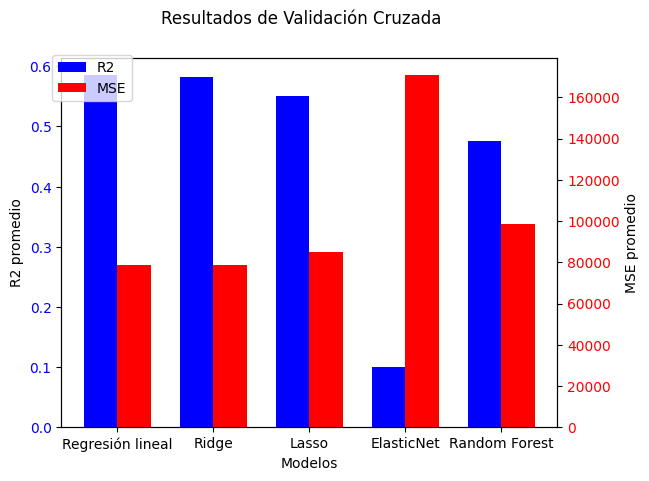

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de ejemplo
categorias = ['Regresión lineal', 'Ridge', 'Lasso', 'ElasticNet', 'Random Forest']
valores1 = [np.mean(r2_scores_rl), np.mean(r2_scores_ridge), np.mean(r2_scores_lasso),
            np.mean(r2_scores_elastic), np.mean(r2_scores_rf)]
valores2 = [np.mean(mse_scores_rl), np.mean(mse_scores_ridge), np.mean(mse_scores_lasso),
            np.mean(mse_scores_elastic), np.mean(mse_scores_rf)]

# Configuración de las barras
ancho_barras = 0.35  # Ancho de las barras
x = np.arange(len(categorias))  # Posiciones de las categorías

# Crear el gráfico de barras
fig, ax1 = plt.subplots()

# Crear el primer conjunto de barras en el primer eje
barras1 = ax1.bar(x - ancho_barras/2, valores1, ancho_barras, label='R2', color='b')
ax1.set_xlabel('Modelos')
ax1.set_ylabel('R2 promedio')
ax1.tick_params(axis='y', labelcolor='b')

# Crear el segundo eje
ax2 = ax1.twinx()

# Crear el segundo conjunto de barras en el segundo eje
barras2 = ax2.bar(x + ancho_barras/2, valores2, ancho_barras, label='MSE', color='r')
ax2.set_ylabel('MSE promedio')
ax2.tick_params(axis='y', labelcolor='r')

# Añadir etiquetas y título
ax1.set_xticks(x)
ax1.set_xticklabels(categorias)
fig.suptitle('Resultados de Validación Cruzada')

# Añadir leyendas
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))

# Mostrar el gráfico
plt.show()

Modelo final utilizando el mejor R2

In [48]:
import joblib

modelo_final = LinearRegression()

modelo_final.fit(x, y)

# Guardar el modelo entrenado en un archivo
joblib_file = "final_linear_regression_model_int.pkl"
joblib.dump(modelo_final, joblib_file)

print(f"Modelo guardado en {joblib_file}")

ValueError: Expected 2D array, got 1D array instead:
array=[0 1 2 3 4].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [ ]:
modelo_final.coef_

array([[-1.85286185e+01,  1.19651974e+01,  9.85272974e-12,
         8.21420635e-01, -9.56836633e+01, -4.24361774e+01,
        -4.59047782e+01,  1.98222873e+01,  1.92834744e+02,
        -2.79859431e+01, -5.56682032e+01,  8.56940684e+01,
         6.49696484e+01,  6.25684874e+01, -1.40900973e+02,
         3.27874327e+01, -3.09030845e+01,  3.32886603e+01,
        -5.57243207e+01,  6.95420237e+01,  8.97445729e+01,
         8.28963475e+01, -2.16001608e+01,  1.07884981e+01,
         4.43243894e+01, -3.35127267e+01, -3.68352302e-02,
        -1.09347438e-01,  7.07969137e+01, -1.47733204e+02,
        -3.52144683e+02, -2.06130927e+01,  9.28924870e+02,
         2.28832018e+02,  1.44405568e+02,  9.72803303e+02,
         5.75137455e+01,  1.60048156e+02, -9.23310415e+00,
         9.54282811e+02, -2.03666064e+02,  8.11365013e+01,
         2.03135409e+02, -1.19475629e+02, -2.18288053e+02,
        -2.56276573e+02, -2.27559016e+02,  8.87888779e+02,
         3.80957834e+02, -1.17478533e+02,  1.87867910e+0

In [ ]:
import joblib
import pandas as pd

# Cargar el modelo entrenado desde el archivo
joblib_file = "final_linear_regression_model_int.pkl"
modelo_final = joblib.load(joblib_file)

# Obtener los nombres de las características
feature_names = x.columns

# Obtener los coeficientes (betas) y el intercepto
coeficientes = modelo_final.coef_.flatten()  # Flatten the coefficients array
intercepto = modelo_final.intercept_

# Crear un DataFrame para mostrar los coeficientes con sus correspondientes características
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coeficientes})

print("Intercepto:", intercepto)
print("Coeficientes (betas) y sus correspondientes características:")
print(coef_df)


# Exportar el DataFrame a un archivo CSV
csv_file = "coeficientes_modelo_final.csv"
coef_df.to_csv(csv_file, index=False)

print(f"Coeficientes exportados a {csv_file}")

Intercepto: [415.05964949]
Coeficientes (betas) y sus correspondientes características:
        Feature   Coefficient
0     bathrooms -1.852862e+01
1      bedrooms  1.196520e+01
2     has_photo  9.852730e-12
3   square_feet  8.214206e-01
4            AC -9.568366e+01
..          ...           ...
72     state_VA  2.451107e+02
73     state_VT  3.167672e+02
74     state_WA  5.193766e+02
75     state_WI  6.218079e+01
76     state_WV -2.338103e+02

[77 rows x 2 columns]
Coeficientes exportados a coeficientes_modelo_final.csv
